# Stage 2 classifiers — Architecture A and B

This notebook trains and evaluates the second-stage classifier for each pipeline architecture:

- **Stage 2A**: spam vs phishing — only runs on messages Stage 1A flagged as suspicious
- **Stage 2B**: ham vs spam — only runs on messages Stage 1B didn't call phishing

Both stages use bigrams (ngram_range=(1,2)) since short phrases like "verify account" or "click here" are more distinctive than single words.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle, os

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

BASE = "../.."

os.makedirs(f"{BASE}/models/07", exist_ok=True)
os.makedirs(f"{BASE}/reports/figures/07", exist_ok=True)

## Stage 2A — spam vs phishing

Stage 2A only sees messages Stage 1A flagged as suspicious. Its job is to tell spam from phishing, which is the harder part — both use similar language (urgency, links, account references).

A quick look at the most common words reveals whether they're distinguishable at all.

In [2]:
train_2a = pd.read_csv(f"{BASE}/data/processed/07/stage2a_train.csv")
test_2a  = pd.read_csv(f"{BASE}/data/processed/07/stage2a_test.csv")
X_train_2a, y_train_2a = train_2a["message"], train_2a["label"]
X_test_2a,  y_test_2a  = test_2a["message"],  test_2a["label"]

print("train:", y_train_2a.value_counts().to_dict())
print("test: ", y_test_2a.value_counts().to_dict())

train: {'spam': 200219, 'phishing': 68667}
test:  {'spam': 50055, 'phishing': 17167}


In [3]:
def top_words(messages, n=10):
    cv = CountVectorizer(stop_words="english", max_features=500)
    X  = cv.fit_transform(messages)
    freq  = X.toarray().sum(axis=0)
    vocab = cv.get_feature_names_out()
    idx   = freq.argsort()[::-1][:n]
    return [vocab[i] for i in idx]

print("spam:",     top_words(train_2a.loc[y_train_2a == "spam",     "message"]))
print("phishing:", top_words(train_2a.loc[y_train_2a == "phishing", "message"]))

spam: ['account', 'rs', '2008', '10', 'email', 'aug', 'claim', 'apply', 'company', 'free']
phishing: ['escapenumber', 'escapelong', 'com', 'http', 'cescapenumber', 'bescapenumber', 'aescapenumber', 'company', 'email', 'www']


In [4]:
vec_2a = TfidfVectorizer(stop_words="english", max_features=3000, ngram_range=(1, 2))
X_train_2a_tf = vec_2a.fit_transform(X_train_2a)
X_test_2a_tf  = vec_2a.transform(X_test_2a)

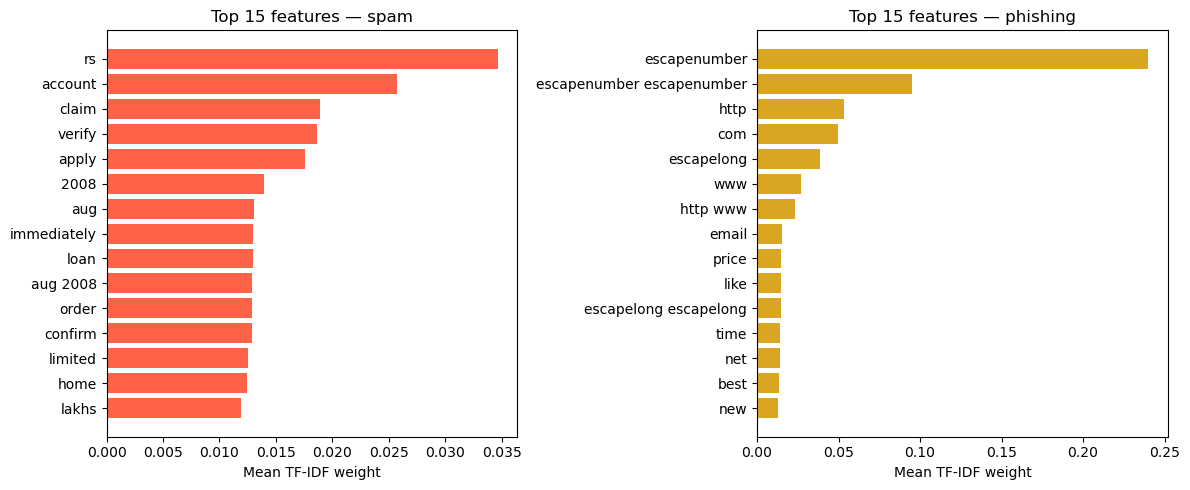

In [5]:
feature_names_2a = vec_2a.get_feature_names_out()
top_n = 15

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, label, color in zip(axes, ["spam", "phishing"], ["tomato", "goldenrod"]):
    mask = y_train_2a.values == label
    mean_scores = np.asarray(X_train_2a_tf[mask].mean(axis=0)).flatten()
    top_idx = mean_scores.argsort()[-top_n:]
    ax.barh(feature_names_2a[top_idx], mean_scores[top_idx], color=color)
    ax.set_title(f"Top {top_n} features — {label}")
    ax.set_xlabel("Mean TF-IDF weight")

plt.tight_layout()
plt.show()

In [6]:
candidates_2a = {
    "LogisticRegression": LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    "MultinomialNB":      MultinomialNB(alpha=1.0),
}

cv_results_2a = {}
for name, model in candidates_2a.items():
    scores = cross_val_score(model, X_train_2a_tf, y_train_2a, cv=5, scoring="f1_macro")
    cv_results_2a[name] = scores
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

LogisticRegression: 0.9432 (+/- 0.0005)
MultinomialNB: 0.9132 (+/- 0.0013)


In [7]:
best_name_2a  = max(cv_results_2a, key=lambda k: cv_results_2a[k].mean())
best_model_2a = candidates_2a[best_name_2a]
best_model_2a.fit(X_train_2a_tf, y_train_2a)
print("best:", best_name_2a)

best: LogisticRegression


In [8]:
y_pred_2a = best_model_2a.predict(X_test_2a_tf)

print(f"accuracy: {accuracy_score(y_test_2a, y_pred_2a):.4f}\n")
print(classification_report(y_test_2a, y_pred_2a))

accuracy: 0.9566

              precision    recall  f1-score   support

    phishing       0.90      0.93      0.92     17167
        spam       0.98      0.97      0.97     50055

    accuracy                           0.96     67222
   macro avg       0.94      0.95      0.94     67222
weighted avg       0.96      0.96      0.96     67222



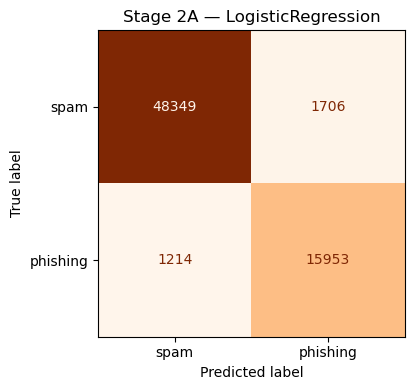

In [9]:
cm_2a = confusion_matrix(y_test_2a, y_pred_2a, labels=["spam", "phishing"])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_2a, display_labels=["spam", "phishing"]).plot(
    ax=ax, cmap="Oranges", colorbar=False
)
ax.set_title(f"Stage 2A — {best_name_2a}")
plt.tight_layout()
plt.savefig(f"{BASE}/reports/figures/07/stage2a_cm.png", dpi=150)
plt.show()

In [10]:
with open(f"{BASE}/models/07/stage2a_model.pkl", "wb") as f:
    pickle.dump(best_model_2a, f)
with open(f"{BASE}/models/07/stage2a_vectorizer.pkl", "wb") as f:
    pickle.dump(vec_2a, f)
print("saved stage2a_model.pkl and stage2a_vectorizer.pkl")

saved stage2a_model.pkl and stage2a_vectorizer.pkl


## Stage 2B — ham vs spam

Stage 2B handles the messages Stage 1B didn't call phishing. It separates legitimate mail from spam. This is usually the easier of the two Stage 2 tasks since ham and spam are more lexically distinct than spam and phishing.

In [11]:
train_2b = pd.read_csv(f"{BASE}/data/processed/07/stage2b_train.csv")
test_2b  = pd.read_csv(f"{BASE}/data/processed/07/stage2b_test.csv")
X_train_2b, y_train_2b = train_2b["message"], train_2b["label"]
X_test_2b,  y_test_2b  = test_2b["message"],  test_2b["label"]

print("train:", y_train_2b.value_counts().to_dict())
print("test: ", y_test_2b.value_counts().to_dict())

train: {'spam': 200219, 'ham': 138621}
test:  {'spam': 50055, 'ham': 34655}


In [12]:
print("ham:",  top_words(train_2b.loc[y_train_2b == "ham",  "message"]))
print("spam:", top_words(train_2b.loc[y_train_2b == "spam", "message"]))

ham: ['escapenumber', 'enron', 'escapelong', 'com', 'http', 'ect', 'subject', 'new', 'message', 'www']
spam: ['account', 'rs', '2008', '10', 'email', 'aug', 'claim', 'apply', 'company', 'free']


In [13]:
vec_2b = TfidfVectorizer(stop_words="english", max_features=3000, ngram_range=(1, 2))
X_train_2b_tf = vec_2b.fit_transform(X_train_2b)
X_test_2b_tf  = vec_2b.transform(X_test_2b)

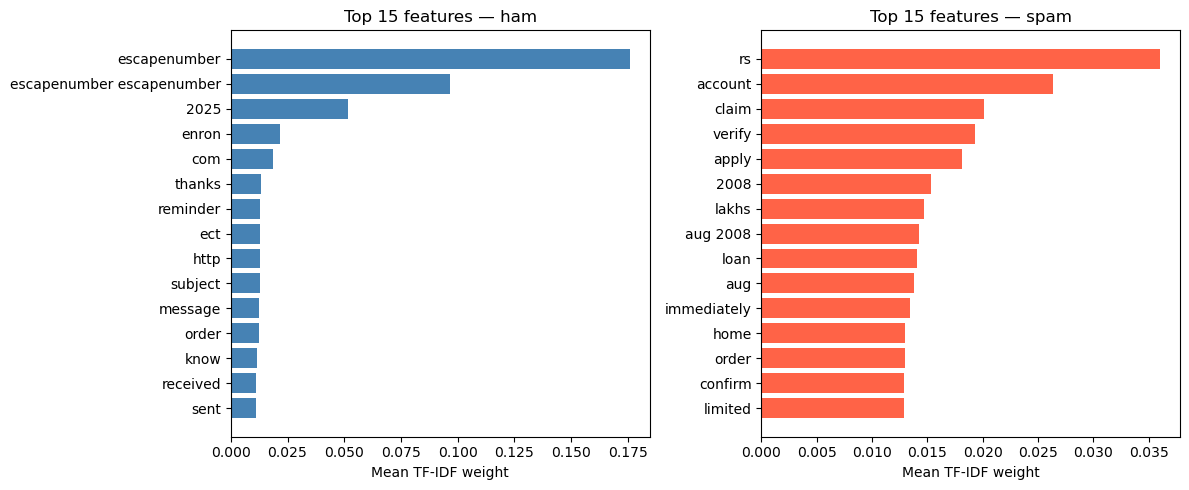

In [14]:
feature_names_2b = vec_2b.get_feature_names_out()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, label, color in zip(axes, ["ham", "spam"], ["steelblue", "tomato"]):
    mask = y_train_2b.values == label
    mean_scores = np.asarray(X_train_2b_tf[mask].mean(axis=0)).flatten()
    top_idx = mean_scores.argsort()[-top_n:]
    ax.barh(feature_names_2b[top_idx], mean_scores[top_idx], color=color)
    ax.set_title(f"Top {top_n} features — {label}")
    ax.set_xlabel("Mean TF-IDF weight")

plt.tight_layout()
plt.show()

In [15]:
candidates_2b = {
    "LogisticRegression": LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    "MultinomialNB":      MultinomialNB(alpha=1.0),
}

cv_results_2b = {}
for name, model in candidates_2b.items():
    scores = cross_val_score(model, X_train_2b_tf, y_train_2b, cv=5, scoring="f1_macro")
    cv_results_2b[name] = scores
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

LogisticRegression: 0.9930 (+/- 0.0001)
MultinomialNB: 0.9579 (+/- 0.0008)


In [16]:
best_name_2b  = max(cv_results_2b, key=lambda k: cv_results_2b[k].mean())
best_model_2b = candidates_2b[best_name_2b]
best_model_2b.fit(X_train_2b_tf, y_train_2b)
print("best:", best_name_2b)

best: LogisticRegression


In [17]:
y_pred_2b = best_model_2b.predict(X_test_2b_tf)

print(f"accuracy: {accuracy_score(y_test_2b, y_pred_2b):.4f}\n")
print(classification_report(y_test_2b, y_pred_2b))

accuracy: 0.9931

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99     34655
        spam       0.99      0.99      0.99     50055

    accuracy                           0.99     84710
   macro avg       0.99      0.99      0.99     84710
weighted avg       0.99      0.99      0.99     84710



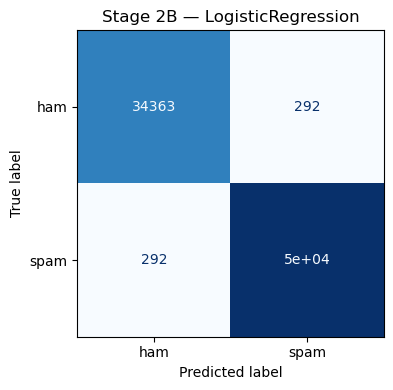

In [18]:
cm_2b = confusion_matrix(y_test_2b, y_pred_2b, labels=["ham", "spam"])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_2b, display_labels=["ham", "spam"]).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title(f"Stage 2B — {best_name_2b}")
plt.tight_layout()
plt.savefig(f"{BASE}/reports/figures/07/stage2b_cm.png", dpi=150)
plt.show()

In [19]:
with open(f"{BASE}/models/07/stage2b_model.pkl", "wb") as f:
    pickle.dump(best_model_2b, f)
with open(f"{BASE}/models/07/stage2b_vectorizer.pkl", "wb") as f:
    pickle.dump(vec_2b, f)
print("saved stage2b_model.pkl and stage2b_vectorizer.pkl")

saved stage2b_model.pkl and stage2b_vectorizer.pkl
